## Assignment 2 Topic 3


### Step 0. Preparation 

In [31]:
# 0.1 Load datasets and libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Transaction data: Contains all customer purchase transactions
df = pd.read_csv("C:/Users/步步高点读机/Desktop/UCL MS/Programming for analytics/练习/Assignment_2/data/csv/transaction_data.csv")
# Demographic data: Contains household demographic information
dg = pd.read_csv("C:/Users/步步高点读机/Desktop/UCL MS/Programming for analytics/练习/Assignment_2/data/csv/hh_demographic.csv")
# Product data: Contains product category and description information
pr = pd.read_csv("C:/Users/步步高点读机/Desktop/UCL MS/Programming for analytics/练习/Assignment_2/data/csv/product.csv")

In [32]:
# 0.2 Check for missing values

# Define function to detect and summarize missing data in dataframes
def missing(dataframe, df_name="DataFrame"):
    missing = dataframe.isnull().sum()
    missing_pct = (missing / len(dataframe)) * 100

    # Show onlymissing_sum columns with missing values
    if missing.sum() > 0 :
        print(f"There is {missing.sum()} missing values in {df_name}") 
        missing_summary = pd.DataFrame({
        'Missing_Count': missing,
        'Percentage': missing_pct
        })
        missing_summary[missing_summary['Missing_Count'] > 0]
        print(missing_summary[missing_summary['Missing_Count'] > 0])
    else:
        print(f"There is no missing values in {df_name}")

# Check all three datasets for missing values
missing(df,"transaction data")
missing(dg,"demographic data")
missing(pr,"product data")

There is no missing values in transaction data
There is no missing values in demographic data
There is no missing values in product data


In [33]:
# 0.3 Check for duplicate records

# Define function to detect duplicate rows in dataframes
def duplicate(dataframe, df_name="DataFrame"):
    duplicates = dataframe.duplicated().sum()

    if duplicates > 0:
        print("\nExample duplicate rows in {df_name}:")
        print(dataframe[dataframe.duplicated(keep=False)].head(4))
    else:
        print(f"There is no duplicate values in {df_name}")

# Check all three datasets for duplicates
duplicate(df,"transaction data")
duplicate(dg,"demographic data")
duplicate(pr,"product data")

There is no duplicate values in transaction data
There is no duplicate values in demographic data
There is no duplicate values in product data


### Step 1. Customer Purchase History Construction 

In [34]:
# 1.1 Total revenue over 2-year period 
total_revenue_per_household = df.groupby('household_key')['SALES_VALUE'].sum()

In [35]:
# 1.2 Purchase frequency (number of transactions) 
frequency_per_household = df.groupby('household_key')['BASKET_ID'].nunique()

In [36]:
# 1.3 Average basket size
sum_per_basket = df.groupby(['household_key','BASKET_ID'])['SALES_VALUE'].sum()
avg_basket_size_per_household = sum_per_basket.groupby('household_key').mean()

In [37]:
# 1.4 Product diversity
product_diversity_per_household = df.groupby('household_key')['PRODUCT_ID'].nunique()

In [38]:
# 1.5 Recency of last purchase 
last_day = df['DAY'].max() 
max_day_per_household = df.groupby('household_key')['DAY'].max()
recency_per_household = last_day - max_day_per_household

In [39]:
# 1.6 Purchase  
basket_std_per_household = sum_per_basket.std()
purchase_consistency_per_household = basket_std_per_household / avg_basket_size_per_household

In [40]:
# Create comprehensive customer profile dataframe
customer_profile = pd.DataFrame({
    'total_revenue' : total_revenue_per_household ,
    'frequency' : frequency_per_household,
    'average_basket_size' : avg_basket_size_per_household,
    'product_diversity' : product_diversity_per_household,
    'recency' : recency_per_household,
    'consistency' : purchase_consistency_per_household   
})

### Step 2. CLV Calculation

In [41]:
# 2.1 Calculate Historic CLV
customer_profile['historic_clv'] = customer_profile['total_revenue']

In [42]:
# 2.2 Annualized CLV 

# Calculate active years for each household
household_timespan = df.groupby('household_key')['DAY'].max() - df.groupby('household_key')['DAY'].min()
active_years_per_household = household_timespan / 365

# Annualized CLV = Historic CLV / Active Years
customer_profile['annualized_clv'] = customer_profile['historic_clv'] / active_years_per_household

In [43]:
# 2.3 Calculate Predicted Future Value

# To predict Retention Possibilities:
recency_list = list(customer_profile['recency'])
frequency_list = list(customer_profile['frequency'])
purchase_consistency_list = list(customer_profile['product_diversity'])

# Calculate percentiles for segmentation thresholds - Dealing with skewed data
recencies_ptile = np.percentile(recency_list,[40,65,85])  # Right-skewed: Most customers shop recently
frequencies_ptile = np.percentile(frequency_list,[15,35,60])  # Right-skewed: Most customers shop infrequently, few shop very frequently
consistency_ptile = np.percentile(purchase_consistency_list,[25,50,75])

def calculate_retention_prob(row):
    base_rate = 0.45

    # Recency bonus : The lower the better
    if row['recency'] <= recencies_ptile[0]: 
        recency_bonus = 0.25
    elif row['recency'] <= recencies_ptile[1]: 
        recency_bonus = 0.15
    elif row['recency'] <= recencies_ptile[2]: 
        recency_bonus = 0.05
    else:
        recency_bonus = -0.15
    
    # Frequency bonus : The higher the better
    if row['frequency'] >= frequencies_ptile[2]: 
        frequency_bonus = 0.20
    elif row['frequency'] >= frequencies_ptile[1]: 
        frequency_bonus = 0.13
    elif row['frequency'] >= frequencies_ptile[0]: 
        frequency_bonus = 0.05
    else:
        frequency_bonus = -0.10

    # Consistency bonus : The lower the better
    if row['product_diversity'] <= consistency_ptile[0]: 
        consistency_bonus = 0.15
    elif row['product_diversity'] <= consistency_ptile[1]: 
        consistency_bonus = 0.10
    elif row['product_diversity'] <= consistency_ptile[2]: 
        consistency_bonus = 0.05
    else:
        consistency_bonus = -0.05

    # Combine bonuses and apply bounds
    estimated_retention_prob = base_rate + recency_bonus + frequency_bonus + consistency_bonus
    estimated_retention_prob_curved = min(0.95, max(0.20, estimated_retention_prob))

    return estimated_retention_prob_curved

# Calculate retention probability for each customer
customer_profile['retention_prob'] = customer_profile.apply(calculate_retention_prob, axis=1)

# Calculate the predicted CLV：Frequency × Average Basket Size × Retention Probability
customer_profile['predicted_clv'] = customer_profile['frequency'] * customer_profile['average_basket_size'] * customer_profile['retention_prob']


In [44]:
# 2.4 Segmenting the CLV stiers

# Calculate Weighted CLV (Historical clv 20% + Predicted clv 80%)
customer_profile['weighted_clv'] = 0.2 * customer_profile['historic_clv'] + 0.8 * customer_profile['predicted_clv']

# Set segmentation criteria
weighted_clv_list = list(customer_profile['weighted_clv'])

    # print(customer_profile['weighted_clv'].describe()) 
    # The distribution show a strong right-skew
weighted_clv_list_ptile = np.percentile(weighted_clv_list,[20,60])

def household_segmenting(row):
    if row['weighted_clv'] >= weighted_clv_list_ptile[1]: 
        clv_tier = "high"
    elif row['weighted_clv'] >= weighted_clv_list_ptile[0]: 
        clv_tier = "medium"
    else:
        clv_tier = "low"
    return clv_tier

# Apply segmentation to create CLV tiers
customer_profile['clv_tier'] = customer_profile.apply(household_segmenting, axis=1)

### Step 3. High-Value Customer Profiling 

In [45]:
# 3.1 Merged with demographic data and processing
clv_merged_dm = customer_profile.merge(dg,
                     how = "left",
                     on = "household_key")

# Check for missing demographic data
missing(clv_merged_dm, "customer_clv_with_demographic_data")

# Note: High missing rate (67.96%) in demographic variables is expected and acceptable
# Reason: Not all customers provided demographic information during registration

clv_merged_processed = clv_merged_dm.dropna() # Keep only customers with complete demographic data

There is 11893 missing values in customer_clv_with_demographic_data
                   Missing_Count  Percentage
classification_1            1699       67.96
classification_2            1699       67.96
classification_3            1699       67.96
HOMEOWNER_DESC              1699       67.96
classification_5            1699       67.96
classification_4            1699       67.96
KID_CATEGORY_DESC           1699       67.96


In [46]:
# 3.2 Dominant demographic profile - High CLV Customers
high_clv_merged = clv_merged_processed[clv_merged_processed['clv_tier'] == "high"]

# Extract demographic column names
dg_list = list(dg.columns)
dg_list.remove("household_key")

# Analyze each demographic variable to find dominant characteristics
demographic_profile = []

for col in dg_list:
    if col in high_clv_merged.columns:
        value_counts = high_clv_merged[col].value_counts()
        dominant_value = value_counts.index[0]
        dominant_count = value_counts.iloc[0]
        dominant_pct = high_clv_merged[col].value_counts(normalize=True).iloc[0]
        
        demographic_profile.append({
            'Variable': col,
            'Most Common Value': dominant_value,
            'Count': int(dominant_count),
            'Percentage': f"{dominant_pct*100:.1f}%"
        })
        
# Create demographic profile summary table
demographic_profile_df = pd.DataFrame(demographic_profile)

display(demographic_profile_df)

,Variable,Most Common Value,Count,Percentage
0,classification_1,Age Group4,229,36.6%
1,classification_2,X,275,44.0%
2,classification_3,Level5,155,24.8%
3,HOMEOWNER_DESC,Homeowner,401,64.2%
4,classification_5,Group5,203,32.5%
5,classification_4,2,252,40.3%
6,KID_CATEGORY_DESC,None/Unknown,431,69.0%


There is no missing values in transaction merged products data
TOP 10 PRODUCT CATEGORIES - High CLV Customers


,COMMODITY_DESC,COMMODITY_DESC_count,COMMODITY_DESC_pct
0,SOFT DRINKS,53881,0.041540
1,FLUID MILK PRODUCTS,41952,0.032343
2,BAKED BREAD/BUNS/ROLLS,40391,0.031140
3,CHEESE,37502,0.028912
4,BAG SNACKS,32097,0.024745
5,FRZN MEAT/MEAT DINNERS,26701,0.020585
6,YOGURT,24745,0.019077
7,SOUP,23457,0.018084
8,BEEF,23141,0.017841
9,VEGETABLES - SHELF STABLE,22089,0.017030


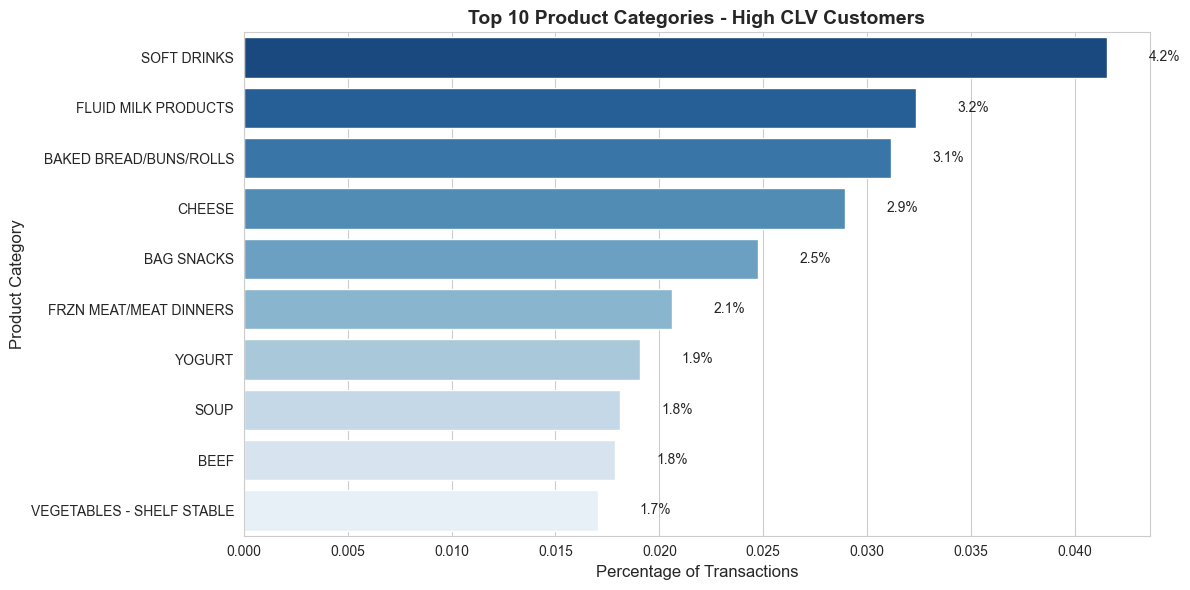

In [47]:
# 3.3 Common product category preferences

# Filter transactions for high CLV customers only
high_clv_household_key_list = high_clv_merged['household_key']
high_clv_transactions = df[df['household_key'].isin(high_clv_household_key_list)]

# Merge transaction data with product information
high_clv_transactions_with_products = high_clv_transactions.merge(pr,
                                                                how = 'left',
                                                                on = 'PRODUCT_ID')

# Check data quality after merge
missing(high_clv_transactions_with_products,"transaction merged products data")

# Define reusable function for preference analysis
def analyze_preference(dataframe, column_name, top_n=None, sort_by_index=False):

    # Calculate frequency
    frequency = dataframe[column_name].value_counts()
    
    # Get top N if specified
    if top_n:
        frequency = frequency.head(top_n)
    
    # Create result dataframe
    result = pd.DataFrame({
        f'{column_name}': frequency.index,
        f'{column_name}_count': frequency.values,
        f'{column_name}_pct': frequency.values / dataframe[column_name].value_counts().sum()
    })
    
    # Sort by index if needed
    if sort_by_index:
        result = result.sort_values(f'{column_name}')
    
    return result

# Analyze top 10 product categories purchased by high CLV customers
top_10_categories = analyze_preference(high_clv_transactions_with_products, 'COMMODITY_DESC', 
                                       top_n=10)

# Display table
print("TOP 10 PRODUCT CATEGORIES - High CLV Customers")
print("="*80)
display(top_10_categories)

# Visualization - Seaborn Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_categories, 
            y='COMMODITY_DESC', 
            x='COMMODITY_DESC_pct',
            hue='COMMODITY_DESC',
            palette='Blues_r')
plt.xlabel('Percentage of Transactions', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.title('Top 10 Product Categories - High CLV Customers', fontsize=14, fontweight='bold')

# Add percentage labels
for i, v in enumerate(top_10_categories['COMMODITY_DESC_pct']):
    plt.text(v + 0.002, i, f'{v*100:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()


In [48]:
# 3.4 Shopping patterns 

# Extract time features from transaction data
high_clv_transactions_with_products['transaction_hour'] = high_clv_transactions_with_products['TRANS_TIME'] // 100

# Categorize hours into time periods
def categorize_time(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'
    
high_clv_transactions_with_products['time_period'] = high_clv_transactions_with_products['transaction_hour'].apply(categorize_time)

# Extract day of week features
high_clv_transactions_with_products['day_of_week'] = high_clv_transactions_with_products['DAY'] % 7 # 0 for Sunday

# Categorize into weekday vs weekend
def categorize_day(day):
    if 1 <= day <= 5:
        return 'Weekday'
    else:
        return 'Weekend' 
    
high_clv_transactions_with_products['week_type'] = high_clv_transactions_with_products['day_of_week'].apply(categorize_day)


# Analyze time preferences
time_period_preference = analyze_preference(high_clv_transactions_with_products, 'time_period')
hour_preference = analyze_preference(high_clv_transactions_with_products, 'transaction_hour')

# Analyze day preferences
day_preference = analyze_preference(high_clv_transactions_with_products, 'day_of_week')
week_type_preference = analyze_preference(high_clv_transactions_with_products, 'week_type')

# Analyze store preferences
store_preference = analyze_preference(high_clv_transactions_with_products, 'STORE_ID', top_n=10)


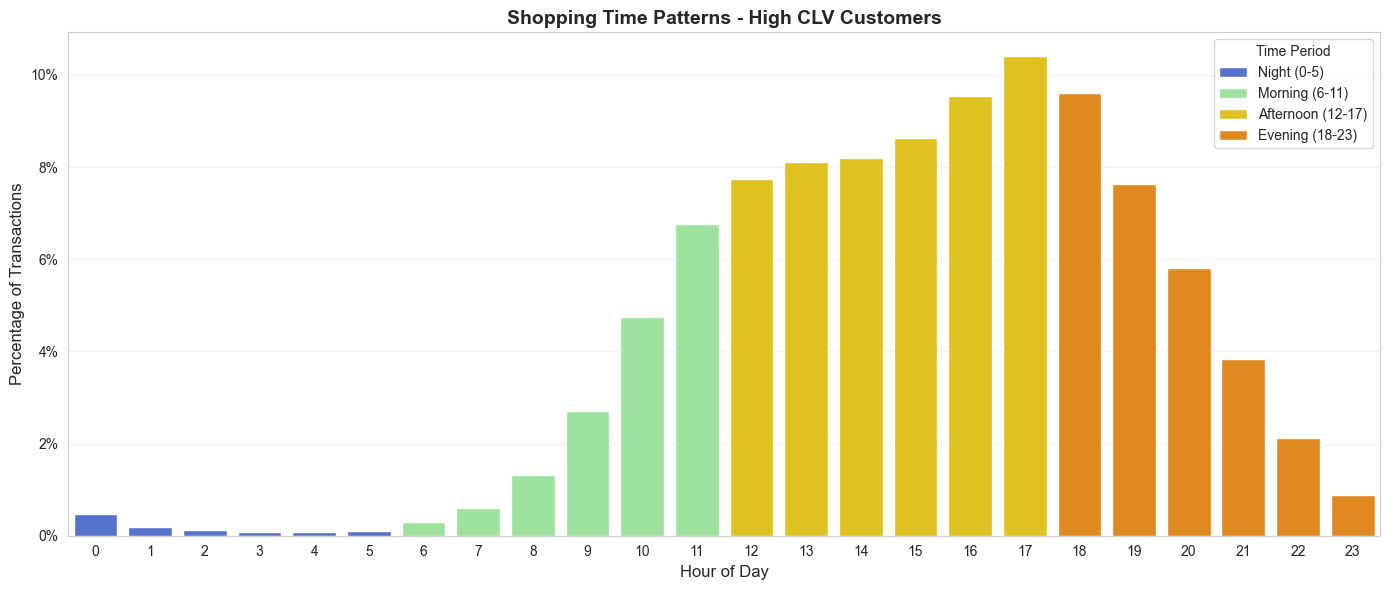

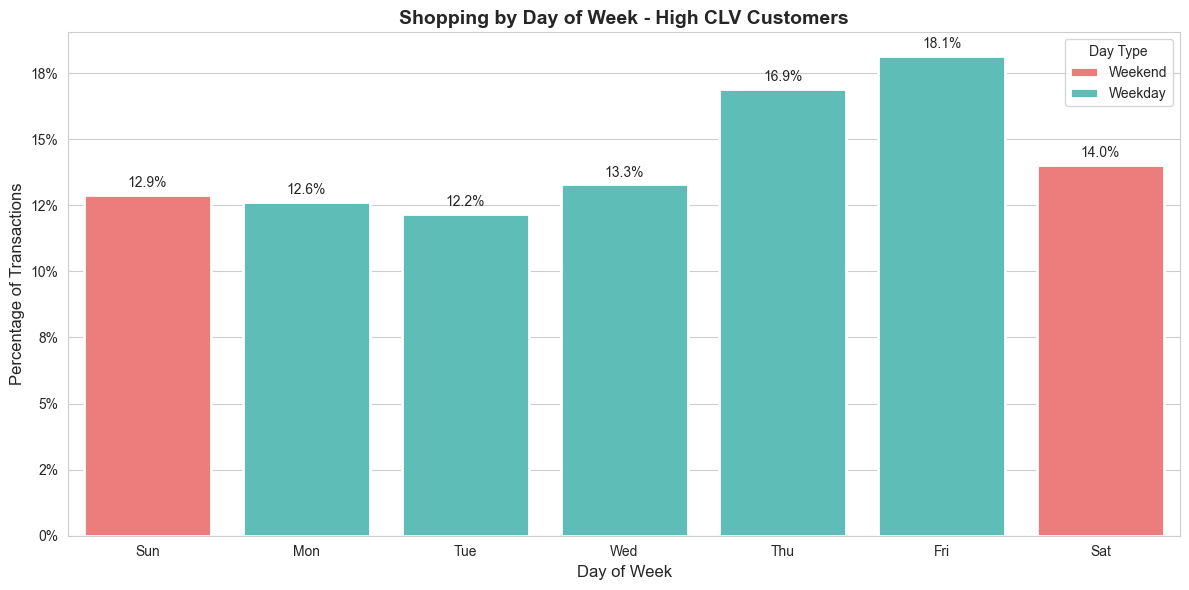

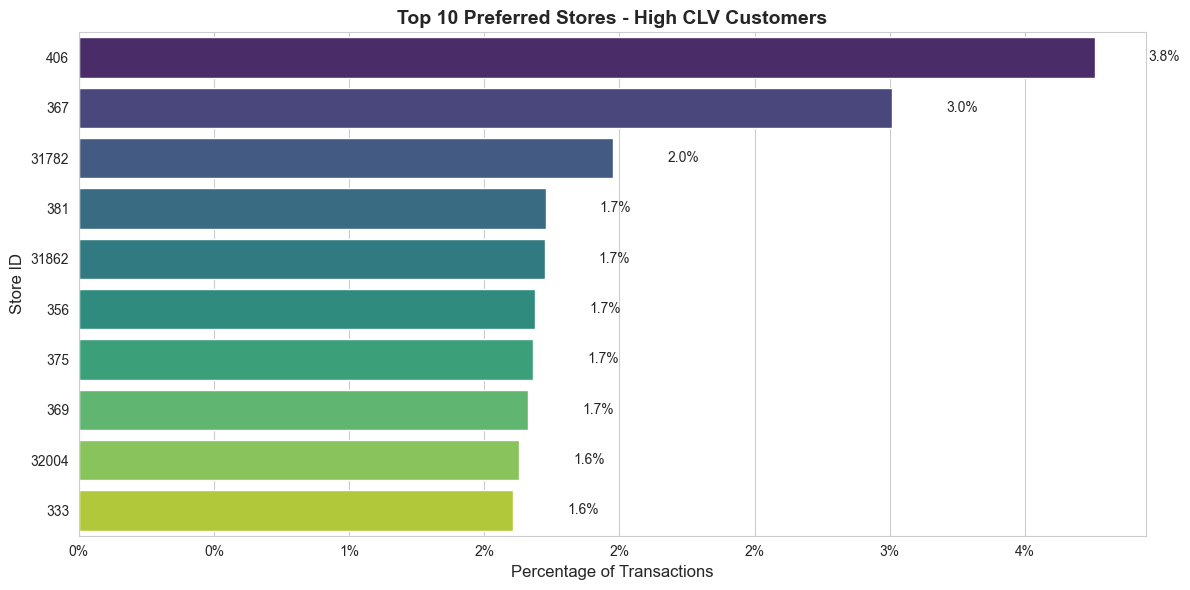

In [49]:
# ===== Figure 1: Hourly Bar Chart with Time Period Colors =====
plt.figure(figsize=(14, 6))

# Prepare data with period labels
hour_preference_sorted = hour_preference.sort_values('transaction_hour').copy()
hour_preference_sorted['period'] = hour_preference_sorted['transaction_hour'].apply(
    lambda x: 'Morning (6-11)' if 6 <= x < 12 
    else 'Afternoon (12-17)' if 12 <= x < 18 
    else 'Evening (18-23)' if 18 <= x < 24 
    else 'Night (0-5)'
)

# Plot with seaborn
sns.barplot(data=hour_preference_sorted,
            x='transaction_hour',
            y='transaction_hour_pct',
            hue='period',
            palette={'Morning (6-11)': '#90EE90', 
                    'Afternoon (12-17)': '#FFD700',
                    'Evening (18-23)': '#FF8C00',
                    'Night (0-5)': '#4169E1'},
            legend=True,
            edgecolor='white',
            linewidth=1)

plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Percentage of Transactions', fontsize=12)
plt.title('Shopping Time Patterns - High CLV Customers', fontsize=14, fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(range(0, 24))
plt.legend(title='Time Period', loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# ===== Figure 2: Day of Week =====
plt.figure(figsize=(12, 6))

day_preference_sorted = day_preference.sort_values('day_of_week').copy()
day_names = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
day_preference_sorted['day_name'] = day_preference_sorted['day_of_week'].map(day_names)
day_preference_sorted['week_type'] = day_preference_sorted['day_of_week'].apply(
    lambda x: 'Weekend' if x in [0, 6] else 'Weekday'
)

sns.barplot(data=day_preference_sorted,
            x='day_name',
            y='day_of_week_pct',
            hue='week_type',
            palette={'Weekday': '#4ECDC4', 'Weekend': '#FF6B6B'},
            legend=True,
            edgecolor='white',
            linewidth=2)

plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Percentage of Transactions', fontsize=12)
plt.title('Shopping by Day of Week - High CLV Customers', fontsize=14, fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
plt.legend(title='Day Type', loc='upper right', fontsize=10)

for i, v in enumerate(day_preference_sorted['day_of_week_pct']):
    plt.text(i, v + 0.003, f'{v*100:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# ===== Figure 3: Top 10 Stores =====
plt.figure(figsize=(12, 6))

store_preference['STORE_ID'] = store_preference['STORE_ID'].astype(str)
sns.barplot(data=store_preference, 
            y='STORE_ID', 
            x='STORE_ID_pct',
            hue='STORE_ID',
            palette='viridis',
            legend=False)

plt.xlabel('Percentage of Transactions', fontsize=12)
plt.ylabel('Store ID', fontsize=12)
plt.title('Top 10 Preferred Stores - High CLV Customers', fontsize=14, fontweight='bold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

for i, v in enumerate(store_preference['STORE_ID_pct']):
    plt.text(v + 0.002, i, f'{v*100:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()


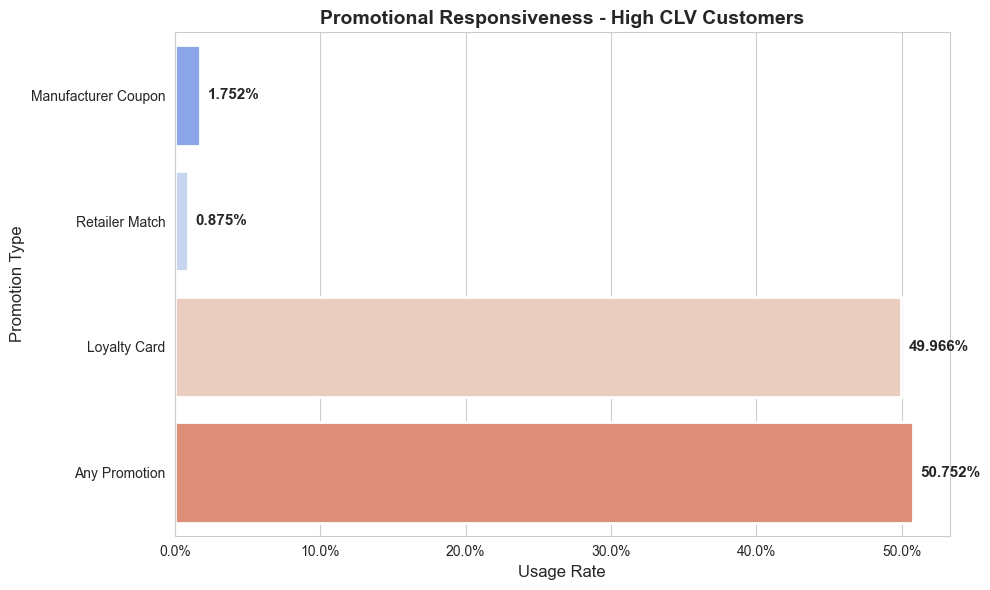

In [50]:
# 3.5 Promotional responsiveness

# Create promotional engagement indicators
# Flag transactions that used each promotion type
high_clv_transactions_with_products['used_manufacturer_coupon'] = high_clv_transactions_with_products['COUPON_DISC'] < 0
high_clv_transactions_with_products['used_retailer_match'] = high_clv_transactions_with_products['COUPON_MATCH_DISC'] < 0
high_clv_transactions_with_products['used_loyalty_disc'] = high_clv_transactions_with_products['RETAIL_DISC'] < 0
high_clv_transactions_with_products['used_any_promo'] = (high_clv_transactions_with_products['used_manufacturer_coupon'] | 
                                                        high_clv_transactions_with_products['used_retailer_match'] | 
                                                        high_clv_transactions_with_products['used_loyalty_disc'])

# Calculate usage rates for each promotion type
promo_usage_rates = pd.DataFrame({
    'promotional_type': ['Manufacturer Coupon', 'Retailer Match', 'Loyalty Card', 'Any Promotion'],
    'usage_rate': [
        high_clv_transactions_with_products['used_manufacturer_coupon'].mean(),
        high_clv_transactions_with_products['used_retailer_match'].mean(),
        high_clv_transactions_with_products['used_loyalty_disc'].mean(),
        high_clv_transactions_with_products['used_any_promo'].mean()
    ]
})

# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(data=promo_usage_rates,
            y='promotional_type',
            x='usage_rate',
            hue='promotional_type',
            palette='coolwarm',
            legend=False,
            edgecolor='white',
            linewidth=2)

plt.ylabel('Promotion Type', fontsize=12)
plt.xlabel('Usage Rate', fontsize=12)
plt.title('Promotional Responsiveness - High CLV Customers', fontsize=14, fontweight='bold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))

# Add percentage labels on bars
for i, v in enumerate(promo_usage_rates['usage_rate']):
    plt.text(v + 0.005, i, f'{v*100:.3f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Step 4. Behavioural Pattern Analysis 

In [51]:
# 4.1 Create comprehensive transaction dataset with product info and CLV tier
df_with_pr = df.merge(pr,
                      how= 'left',
                      on= "PRODUCT_ID")
df_with_pr = df_with_pr.merge(customer_profile[['clv_tier']], how='left', on='household_key')

missing(df_with_pr)


There is no missing values in DataFrame


In [52]:
# 4.2 Extract first 3 months of data for each customer
# Find each customer's first purchase day
first_purchase_day = df_with_pr.groupby('household_key')['DAY'].min()

# Merge back to get relative day (从每个客户第一次购买开始算)
df_with_pr_datetraced = df_with_pr.merge(first_purchase_day.rename('first_day'), 
                               how='left', 
                               on='household_key')
df_with_pr_datetraced['days_since_first'] = df_with_pr_datetraced['DAY'] - df_with_pr_datetraced['first_day']

# Filter first 90 days (约3个月)
df_first_3months = df_with_pr_datetraced[df_with_pr_datetraced['days_since_first'] <= 90].copy()



In [53]:
# 4.3 Extract features from first 3 months

# A. Early Purchase Behaviours
# Calculate basic metrics
early_basic = df_first_3months.groupby('household_key').agg({
    'BASKET_ID': 'nunique',      # early_frequency
    'SALES_VALUE': 'sum',        # early_total_spending
    'PRODUCT_ID': 'nunique',     # early_product_diversity
    'days_since_first': 'max'                 # last purchase day in first 3 months
})
early_basic.columns = ['early_frequency', 'early_total_spending', 'early_product_diversity', 'last_day_3months']

# Calculate early average basket size
sum_per_basket_early = df_first_3months.groupby(['household_key','BASKET_ID'])['SALES_VALUE'].sum()
early_avg_basket = sum_per_basket_early.groupby('household_key').mean().rename('early_avg_basket_size')

# Calculate early consistency (CV of basket size)
basket_std_early = sum_per_basket_early.groupby('household_key').std()
early_inconsistency = (basket_std_early / early_avg_basket).rename('early_inconsistency')

# Fill missing with high value (most inconsistent)
fill_value = np.percentile(early_inconsistency.dropna(), 95)
early_inconsistency = early_inconsistency.fillna(fill_value)

# Calculate early recency (days from last purchase in 3 months to day 90)
early_recency = (90 - early_basic['last_day_3months']).rename('early_recency')

# Combine A features
early_features = pd.concat([early_basic[['early_frequency', 'early_total_spending', 'early_product_diversity']], 
                           early_avg_basket, 
                           early_inconsistency, 
                           early_recency], axis=1)

# B. Product Category Patterns
# Number of different categories purchased
num_categories = df_first_3months.groupby('household_key')['COMMODITY_DESC'].nunique().rename('num_categories_purchased')

# Check if purchased top 3 categories (from your 3.3 analysis: SOFT DRINKS, FLUID MILK PRODUCTS, BAKED BREAD/BUNS/ROLLS)
top_3_categories = ['SOFT DRINKS', 'FLUID MILK PRODUCTS', 'BAKED BREAD/BUNS/ROLLS']
purchased_top_cat = df_first_3months[df_first_3months['COMMODITY_DESC'].isin(top_3_categories)].groupby('household_key')['COMMODITY_DESC'].nunique()
purchased_top_categories = (purchased_top_cat >= 2).astype(int).rename('purchased_top_categories')  # bought at least 2 of top 3

# Combine B features
early_features = pd.concat([early_features, num_categories, purchased_top_categories], axis=1)
early_features['purchased_top_categories'] = early_features['purchased_top_categories'].fillna(0)

# C. Initial Basket Characteristics
# Get first basket for each customer
first_basket = df_first_3months.sort_values('DAY').groupby('household_key').first()
first_basket_features = pd.DataFrame({
    'first_basket_size': df_first_3months.groupby(['household_key', 'BASKET_ID'])['SALES_VALUE'].sum().groupby('household_key').first(),
    'first_basket_items': df_first_3months.groupby(['household_key', 'BASKET_ID'])['PRODUCT_ID'].count().groupby('household_key').first(),
    'first_basket_used_promo': ((first_basket['COUPON_DISC'] < 0) | 
                                (first_basket['COUPON_MATCH_DISC'] < 0) | 
                                (first_basket['RETAIL_DISC'] < 0)).astype(int)
})

# Combine C features
early_features = pd.concat([early_features, first_basket_features], axis=1)

# D. Shopping Pattern Indicators
# Early promo usage rate
df_first_3months['used_any_promo'] = ((df_first_3months['COUPON_DISC'] < 0) | 
                                      (df_first_3months['COUPON_MATCH_DISC'] < 0) | 
                                      (df_first_3months['RETAIL_DISC'] < 0))
early_promo_rate = df_first_3months.groupby('household_key')['used_any_promo'].mean().rename('early_promo_usage_rate')

# Preferred time match (based on 3.4 analysis: Afternoon is preferred)
df_first_3months['transaction_hour'] = df_first_3months['TRANS_TIME'] // 100
df_first_3months['time_period'] = df_first_3months['transaction_hour'].apply(categorize_time)

# Create indicator for Afternoon shopping
df_first_3months['is_afternoon'] = (df_first_3months['time_period'] == 'Afternoon').astype(int)
# Calculate the proportion of Afternoon purchases per customer
preferred_time_rate = df_first_3months.groupby('household_key')['is_afternoon'].mean().rename('preferred_time_match')

# Combine D features
early_features = pd.concat([early_features, early_promo_rate, preferred_time_rate], axis=1)

# Merge with CLV tier and create binary target
early_features = early_features.merge(customer_profile[['clv_tier']], 
                                      how='left', 
                                      on='household_key')

early_features['is_high_clv'] = (early_features['clv_tier'] == 'high').astype(int)

# Save complete dataset with ALL customers (high, medium, low)
early_features_all = early_features.copy()  # 👈 保存完整版本

# Create binary dataset (only high vs low) for modeling
early_features_binary = early_features[early_features['clv_tier'].isin(['high', 'low'])].copy()

# Check and handle missing values
missing(early_features_binary, "early_features_binary")
print(f"High CLV customers: {(early_features_binary['is_high_clv'] == 1).sum()}")
print(f"Low CLV customers: {(early_features_binary['is_high_clv'] == 0).sum()}")

early_features_binary.head()

There is no missing values in early_features_binary
High CLV customers: 1000
Low CLV customers: 500


,early_frequency,early_total_spending,early_product_diversity,early_avg_basket_size,early_inconsistency,early_recency,num_categories_purchased,purchased_top_categories,first_basket_size,first_basket_items,first_basket_used_promo,early_promo_usage_rate,preferred_time_match,clv_tier,is_high_clv
household_key,,,,,,,,,,,,,,,
1,9,511.63,131,56.847778,0.538134,4,66,1.0,78.66,30,1,0.531915,0.574468,high,1
6,39,1163.18,254,29.825128,0.842131,0,90,1.0,53.96,20,0,0.314516,0.688172,high,1
7,5,218.88,68,43.776000,1.097101,23,43,1.0,82.97,26,1,0.712329,0.410959,high,1
8,14,675.80,190,48.271429,1.390587,6,77,1.0,270.74,94,1,0.479821,0.192825,high,1
9,3,61.15,23,20.383333,0.403511,70,17,1.0,15.54,6,0,0.565217,0.739130,low,0


Features used in the model:
['early_frequency', 'early_total_spending', 'early_product_diversity', 'early_avg_basket_size', 'early_inconsistency', 'early_recency', 'num_categories_purchased', 'purchased_top_categories', 'first_basket_size', 'first_basket_items', 'first_basket_used_promo', 'early_promo_usage_rate', 'preferred_time_match']

Feature matrix shape: (1500, 13)
Target distribution:
is_high_clv
1    1000
0     500
Name: count, dtype: int64

Training set: 1200 samples
Test set: 300 samples

MODEL PERFORMANCE SUMMARY
              Metric    Score                           Description
            Accuracy 0.873333                   Overall correctness
Precision (High CLV) 0.905000      Accuracy of High CLV predictions
   Recall (High CLV) 0.905000 Coverage of actual High CLV customers
 F1-Score (High CLV) 0.905000 Harmonic mean of Precision and Recall
             ROC-AUC 0.948050          Model discriminative ability

CONFUSION MATRIX BREAKDOWN
True Negatives (TN):    81 - Corre

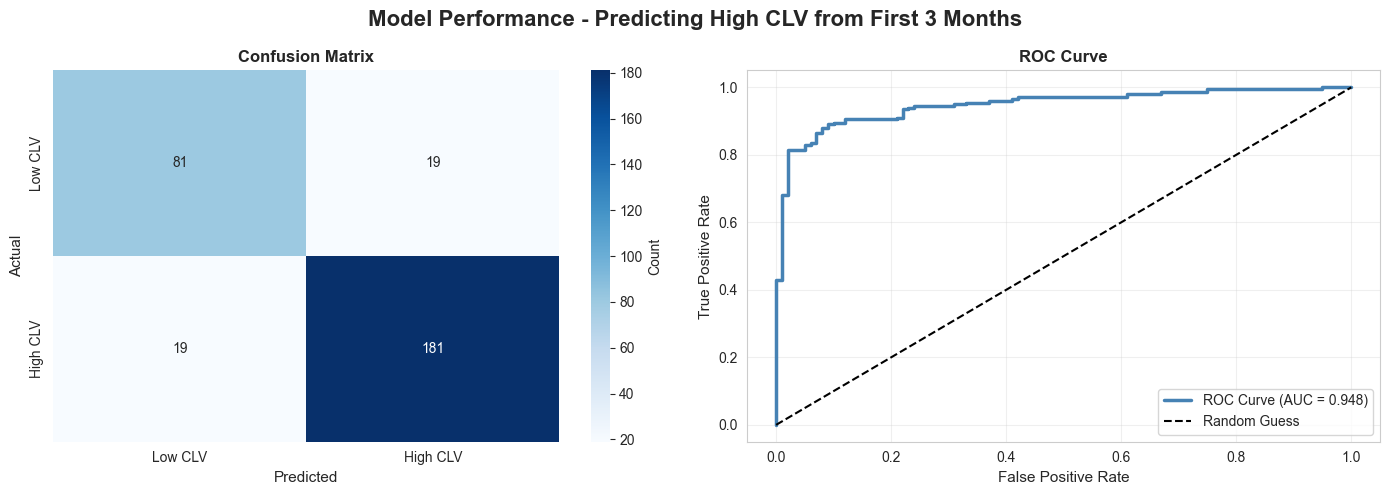

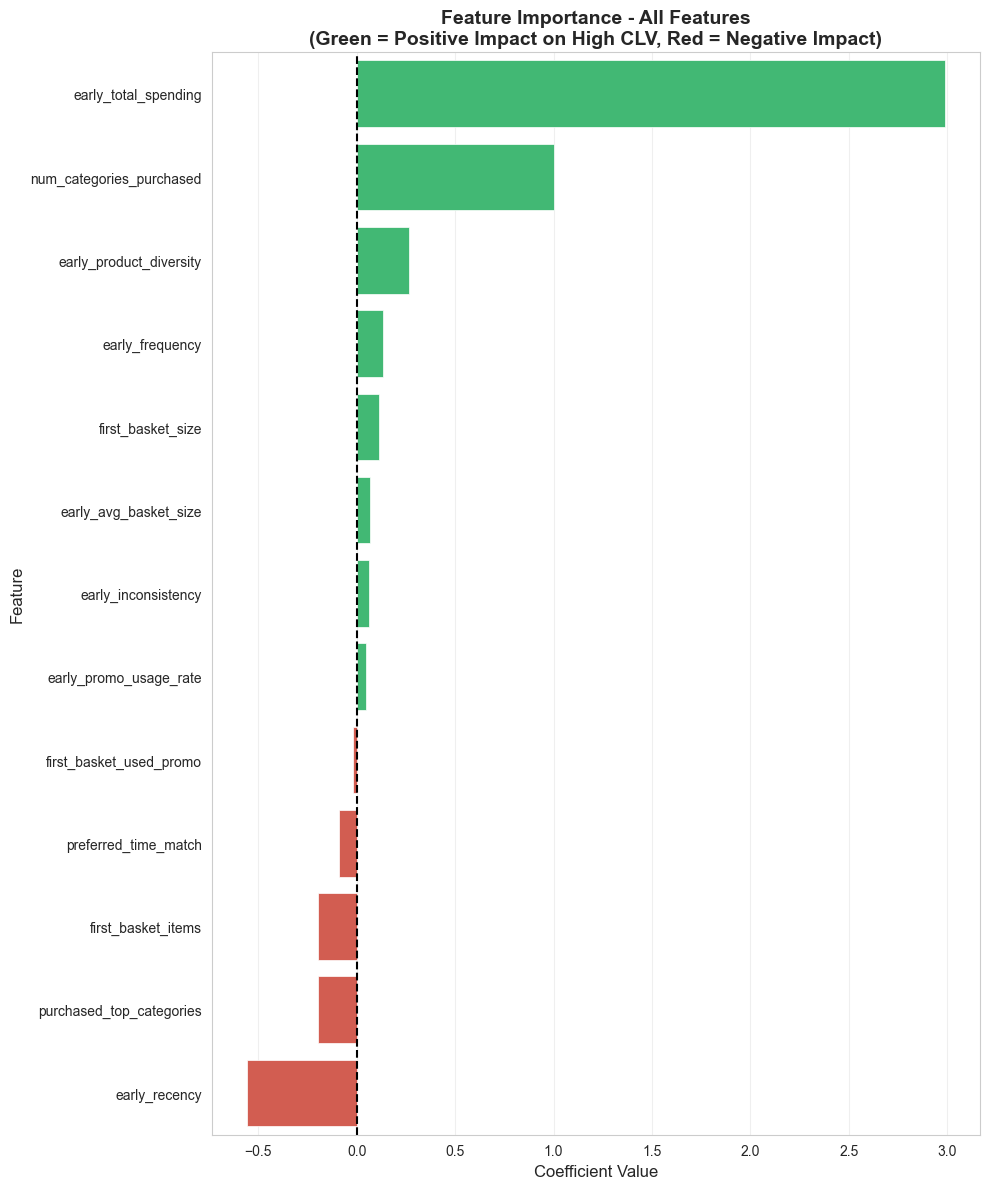

In [54]:
# 4.4 Build Logistic Regression Model

# Set style
sns.set_style("whitegrid")

# Prepare features and target
feature_cols = [col for col in early_features_binary.columns 
                if col not in ['clv_tier', 'is_high_clv', 'last_day_3months']]

X = early_features_binary[feature_cols]
y = early_features_binary['is_high_clv']

print("Features used in the model:")
print(feature_cols)
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test = log_reg.predict(X_test_scaled)
y_pred_proba_test = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

# Create comprehensive evaluation metrics table
evaluation_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (High CLV)', 'Recall (High CLV)', 'F1-Score (High CLV)', 'ROC-AUC'],
    'Score': [
        accuracy_score(y_test, y_pred_test),
        precision_score(y_test, y_pred_test),
        recall_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test),
        roc_auc_score(y_test, y_pred_proba_test)
    ],
    'Description': [
        'Overall correctness',
        'Accuracy of High CLV predictions',
        'Coverage of actual High CLV customers',
        'Harmonic mean of Precision and Recall',
        'Model discriminative ability'
    ]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(evaluation_metrics.to_string(index=False))

print("\n" + "="*60)
print("CONFUSION MATRIX BREAKDOWN")
print("="*60)
print(f"True Negatives (TN):  {tn:>4} - Correctly predicted Low CLV")
print(f"False Positives (FP): {fp:>4} - Low CLV predicted as High")
print(f"False Negatives (FN): {fn:>4} - High CLV predicted as Low ⚠️")
print(f"True Positives (TP):  {tp:>4} - Correctly predicted High CLV")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Top 10)")
print("="*60)
print(feature_importance.head(10).to_string(index=False))
print("\nMost negative coefficients (predicting Low CLV):")
print(feature_importance.tail(5).to_string(index=False))

# ===== Figure 1: Model Performance =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance - Predicting High CLV from First 3 Months', fontsize=16, fontweight='bold')

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low CLV', 'High CLV'], 
            yticklabels=['Low CLV', 'High CLV'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
axes[1].plot(fpr, tpr, linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba_test):.3f})', color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Guess')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ===== Figure 2: All Feature Importance =====
plt.figure(figsize=(10, 12))

# Plot all features
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in feature_importance['coefficient']]
sns.barplot(x='coefficient', 
            y='feature', 
            data=feature_importance, 
            hue='feature', 
            palette=colors, 
            legend=False,
            edgecolor='white',
            linewidth=0.5)

plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance - All Features\n(Green = Positive Impact on High CLV, Red = Negative Impact)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Step 5. Strategic Segmentation 

In [55]:
# 5.1: Use trained model from 4.4 to predict probability for low and medium customers
low_medium_customers = early_features_all[early_features_all['clv_tier'].isin(['low', 'medium'])].copy()

X_low_medium = low_medium_customers[feature_cols]
X_low_medium_scaled = scaler.transform(X_low_medium)
low_medium_customers['high_clv_probability'] = log_reg.predict_proba(X_low_medium_scaled)[:, 1]

# Merge probability back to customer_profile
customer_profile = customer_profile.merge(
    low_medium_customers[['high_clv_probability']],
    how='left',
    on='household_key'
)

In [56]:
# 5.2 Define thresholds for segmentation

# For general segmentation (Whales, Promising)
basket_high = np.percentile(customer_profile['average_basket_size'], 70)
freq_low_general = np.percentile(customer_profile['frequency'], 30)

# For HIGH CLV customer segmentation - calculate thresholds within high CLV group only
high_clv_customers = customer_profile[customer_profile['clv_tier'] == 'high']

freq_high_clv = np.percentile(high_clv_customers['frequency'], 70)  # Top 30% within high CLV
freq_low_clv = np.percentile(high_clv_customers['frequency'], 30)   # Bottom 30% within high CLV

# Recency: LEFT-SKEWED (most customers are recent) → adjust percentiles
recency_low_clv_percentile = np.percentile(high_clv_customers['recency'],30)  # 30th percentile
recency_low_clv = max(recency_low_clv_percentile, 2)  # 取30th percentile或2天，取较大者
recency_high_clv = np.percentile(high_clv_customers['recency'], 90)  # Least recent 10% within high CLV

print("="*70)
print("SEGMENTATION THRESHOLDS")
print("="*70)
print("\nFor High CLV Customer Segmentation (within high CLV group):")
print(f"  High Frequency: >= {freq_high_clv:.0f} purchases (70th %ile within high CLV)")
print(f"  Low Frequency: <= {freq_low_clv:.0f} purchases (30th %ile within high CLV)")
print(f"  Low Recency (recent): <= {recency_low_clv:.0f} days (20th %ile OR min 2 days - left-skewed)")
print(f"    - 30th percentile: {recency_low_clv_percentile:.0f} days")
print(f"    - Using: {recency_low_clv:.0f} days")
print(f"  High Recency (at risk): >= {recency_high_clv:.0f} days (90th %ile within high CLV)")

print("\nFor General Segmentation (all customers):")
print(f"  High Basket: >= ${basket_high:.2f} (70th %ile)")
print(f"  Low Frequency: <= {freq_low_general:.0f} (30th %ile)")
print("="*70)

# Verify distribution
print("\nHigh CLV Customer Metrics:")
print(f"  Frequency - Min: {high_clv_customers['frequency'].min():.0f}, "
      f"Median: {high_clv_customers['frequency'].median():.0f}, "
      f"Max: {high_clv_customers['frequency'].max():.0f}")
print(f"  Recency - Min: {high_clv_customers['recency'].min():.0f}, "
      f"Median: {high_clv_customers['recency'].median():.0f}, "
      f"Max: {high_clv_customers['recency'].max():.0f}")


SEGMENTATION THRESHOLDS

For High CLV Customer Segmentation (within high CLV group):
  High Frequency: >= 210 purchases (70th %ile within high CLV)
  Low Frequency: <= 118 purchases (30th %ile within high CLV)
  Low Recency (recent): <= 2 days (20th %ile OR min 2 days - left-skewed)
    - 30th percentile: 1 days
    - Using: 2 days
  High Recency (at risk): >= 13 days (90th %ile within high CLV)

For General Segmentation (all customers):
  High Basket: >= $36.71 (70th %ile)
  Low Frequency: <= 45 (30th %ile)

High CLV Customer Metrics:
  Frequency - Min: 29, Median: 154, Max: 1300
  Recency - Min: 0, Median: 2, Max: 258


In [57]:
# 5.3 Assign segments based on CLV and behavior

def assign_segment(row):
    
# For HIGH CLV customers - use thresholds within high CLV group
    if row['clv_tier'] == 'high':
        # 1. Champions: Best within high CLV (high frequency + recent)
        if row['frequency'] >= freq_high_clv and row['recency'] <= recency_low_clv:
            return 'Champions'
        
        # 2. At Risk: Worst within high CLV (low frequency + not recent)
        elif row['frequency'] <= freq_low_clv and row['recency'] >= recency_high_clv:
            return 'At Risk'
        
        # 3. Loyal Customers: All remaining high CLV (consistent, moderate behavior)
        else:
            return 'Loyal Customers'
    
    # Whales: high basket size but infrequent (use general thresholds)
    elif row['average_basket_size'] >= basket_high and row['frequency'] <= freq_low_general:
        return 'Whales'
    
    # Promising: low/medium CLV but model predicts high probability
    elif pd.notna(row.get('high_clv_probability')) and row['high_clv_probability'] > 0.6:
        return 'Promising'
    
    # Others: remaining customers
    else:
        return 'Others'

# Apply segmentation
customer_profile['segment'] = customer_profile.apply(assign_segment, axis=1)

# Show segment distribution
print("\n" + "="*70)
print("SEGMENT DISTRIBUTION")
print("="*70)
segment_counts = customer_profile['segment'].value_counts().sort_values(ascending=False)

# Separate 'Others' and sort the rest by count
if 'Others' in segment_counts.index:
    others_count = segment_counts['Others']
    segment_counts_no_others = segment_counts.drop('Others').sort_values(ascending=False)
    # Reorder: put Others at the end
    segment_counts = pd.concat([segment_counts_no_others, pd.Series({'Others': others_count})])
else:
    segment_counts = segment_counts.sort_values(ascending=False)

# Display each segment
total_customers = len(customer_profile)
for segment, count in segment_counts.items():
    pct = count / total_customers * 100
    print(f"  {segment:<20} {count:>5} ({pct:>5.1f}%)")

# Display total
print(f"  {'-'*20} {'-'*5} {'-'*8}")
print(f"  {'TOTAL':<20} {total_customers:>5} ({100.0:>5.1f}%)")


SEGMENT DISTRIBUTION
  Loyal Customers        740 ( 29.6%)
  Promising              470 ( 18.8%)
  Whales                 247 (  9.9%)
  Champions              206 (  8.2%)
  At Risk                 54 (  2.2%)
  Others                 783 ( 31.3%)
  -------------------- ----- --------
  TOTAL                 2500 (100.0%)


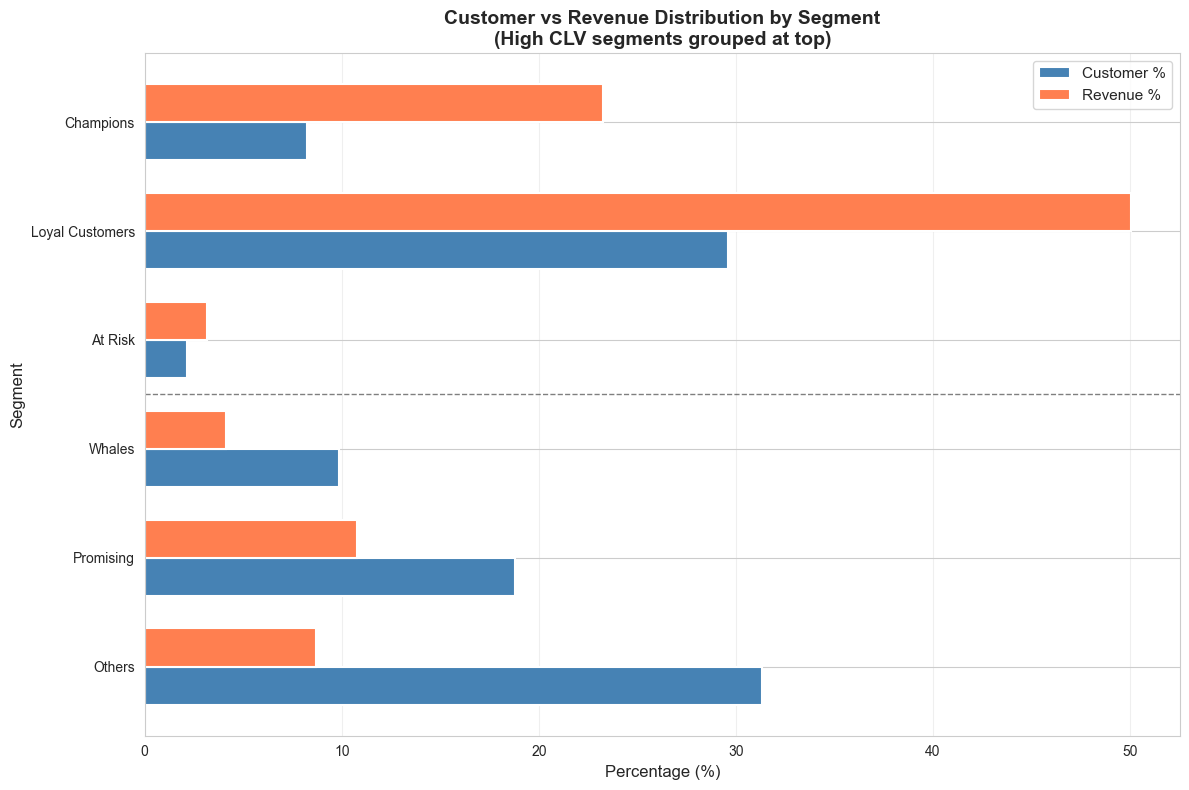

In [62]:
# 5.3 Visualization - Segment Distribution

# Define segment order and Extract data
segment_order = ['Champions', 'Loyal Customers', 'At Risk', 'Whales', 'Promising', 'Others']

segment_counts = customer_profile['segment'].value_counts()
segment_counts = segment_counts.reindex([s for s in segment_order if s in segment_counts.index])

segment_revenue = customer_profile.groupby('segment')['total_revenue'].sum()
segment_revenue = segment_revenue.reindex([s for s in segment_order if s in segment_revenue.index])

# ===== Figure : Customer vs Revenue Comparison (Grouped by CLV tier) =====
plt.figure(figsize=(12, 8))

# Calculate percentages
segment_summary = pd.DataFrame({
    'customer_pct': (segment_counts / len(customer_profile)) * 100,
    'revenue_pct': (segment_revenue / segment_revenue.sum()) * 100
})

# Define custom order: High CLV segments first, then others, Others last
high_clv_segments = ['Champions', 'Loyal Customers', 'At Risk']
other_segments = ['Whales', 'Promising']

custom_order = []
for seg in high_clv_segments:
    if seg in segment_summary.index:
        custom_order.append(seg)
for seg in other_segments:
    if seg in segment_summary.index:
        custom_order.append(seg)
if 'Others' in segment_summary.index:
    custom_order.append('Others')

# Reverse order so top segment appears at top of chart
segment_summary = segment_summary.reindex(custom_order[::-1])

# Plot horizontal grouped bar chart
x = range(len(segment_summary))
width = 0.35

plt.barh([i - width/2 for i in x], segment_summary['customer_pct'], width, 
         label='Customer %', color='steelblue', edgecolor='white', linewidth=1.5)
plt.barh([i + width/2 for i in x], segment_summary['revenue_pct'], width, 
         label='Revenue %', color='coral', edgecolor='white', linewidth=1.5)

plt.yticks(x, segment_summary.index)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Segment', fontsize=12)
plt.title('Customer vs Revenue Distribution by Segment\n(High CLV segments grouped at top)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='x', alpha=0.3)

# Add separator line after High CLV segments (adjust position for reversed order)
if len(high_clv_segments) > 0 and 'Others' in segment_summary.index:
    separator_position = len(segment_summary) - len(high_clv_segments) - 0.5
    plt.axhline(y=separator_position, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()


In [59]:
# 5.4 Calculate segment sizes and aggregate value

# Calculate metrics for all segments
segment_analysis = customer_profile.groupby('segment').agg({
    'total_revenue': 'sum'
})
segment_analysis['customer_count'] = customer_profile.groupby('segment').size()
segment_analysis['customer_pct'] = segment_analysis['customer_count'] / segment_analysis['customer_count'].sum() * 100
segment_analysis['revenue_pct'] = segment_analysis['total_revenue'] / segment_analysis['total_revenue'].sum() * 100
segment_analysis['avg_revenue_per_customer'] = segment_analysis['total_revenue'] / segment_analysis['customer_count']

# Reorder columns
segment_analysis = segment_analysis[['customer_count', 'customer_pct', 'total_revenue', 'revenue_pct', 'avg_revenue_per_customer']]

# Define segment order
high_clv_segments = ['Champions', 'Loyal Customers', 'At Risk']
other_segments = ['Whales', 'Promising', 'Others']

# Display with hierarchical structure
print("\n" + "="*100)
print("SEGMENT ANALYSIS - SIZES AND AGGREGATE VALUE")
print("="*100)

# 1. High CLV segments
print("\nHIGH CLV SEGMENTS:")
print("-" * 100)
high_clv_total_customers = 0
high_clv_total_revenue = 0

for seg in high_clv_segments:
    if seg in segment_analysis.index:
        row = segment_analysis.loc[seg]
        print(f"  {seg:<20} | Customers: {row['customer_count']:>5.0f} ({row['customer_pct']:>5.2f}%) | "
              f"Revenue: ${row['total_revenue']:>12,.2f} ({row['revenue_pct']:>5.2f}%) | "
              f"Avg: ${row['avg_revenue_per_customer']:>8,.2f}")
        high_clv_total_customers += row['customer_count']
        high_clv_total_revenue += row['total_revenue']

# High CLV subtotal
high_clv_pct_customers = (high_clv_total_customers / segment_analysis['customer_count'].sum()) * 100
high_clv_pct_revenue = (high_clv_total_revenue / segment_analysis['total_revenue'].sum()) * 100
high_clv_avg = high_clv_total_revenue / high_clv_total_customers if high_clv_total_customers > 0 else 0

print("-" * 100)
print(f"  {'HIGH CLV SUBTOTAL':<20} | Customers: {high_clv_total_customers:>5.0f} ({high_clv_pct_customers:>5.2f}%) | "
      f"Revenue: ${high_clv_total_revenue:>12,.2f} ({high_clv_pct_revenue:>5.2f}%) | "
      f"Avg: ${high_clv_avg:>8,.2f}")

# 2. Other segments
print("\n" + "="*100)
print("OTHER SEGMENTS:")
print("-" * 100)

for seg in other_segments:
    if seg in segment_analysis.index:
        row = segment_analysis.loc[seg]
        print(f"  {seg:<20} | Customers: {row['customer_count']:>5.0f} ({row['customer_pct']:>5.2f}%) | "
              f"Revenue: ${row['total_revenue']:>12,.2f} ({row['revenue_pct']:>5.2f}%) | "
              f"Avg: ${row['avg_revenue_per_customer']:>8,.2f}")

# 3. Overall total
print("=" * 100)
total_customers = segment_analysis['customer_count'].sum()
total_revenue = segment_analysis['total_revenue'].sum()
overall_avg = total_revenue / total_customers

print(f"  {'OVERALL TOTAL':<20} | Customers: {total_customers:>5.0f} (100.00%) | "
      f"Revenue: ${total_revenue:>12,.2f} (100.00%) | "
      f"Avg: ${overall_avg:>8,.2f}")
print("=" * 100)

# Display the full table for reference
print("\nDETAILED SEGMENT BREAKDOWN TABLE:")
display(segment_analysis.round(2))


SEGMENT ANALYSIS - SIZES AND AGGREGATE VALUE

HIGH CLV SEGMENTS:
----------------------------------------------------------------------------------------------------
  Champions            | Customers:   206 ( 8.24%) | Revenue: $1,872,393.01 (23.24%) | Avg: $9,089.29
  Loyal Customers      | Customers:   740 (29.60%) | Revenue: $4,030,854.88 (50.03%) | Avg: $5,447.10
  At Risk              | Customers:    54 ( 2.16%) | Revenue: $  254,784.12 ( 3.16%) | Avg: $4,718.22
----------------------------------------------------------------------------------------------------
  HIGH CLV SUBTOTAL    | Customers:  1000 (40.00%) | Revenue: $6,158,032.01 (76.43%) | Avg: $6,158.03

OTHER SEGMENTS:
----------------------------------------------------------------------------------------------------
  Whales               | Customers:   247 ( 9.88%) | Revenue: $  332,156.06 ( 4.12%) | Avg: $1,344.76
  Promising            | Customers:   470 (18.80%) | Revenue: $  868,111.04 (10.77%) | Avg: $1,847.04
  

,customer_count,customer_pct,total_revenue,revenue_pct,avg_revenue_per_customer
segment,,,,,
At Risk,54,2.16,254784.12,3.16,4718.22
Champions,206,8.24,1872393.01,23.24,9089.29
Loyal Customers,740,29.60,4030854.88,50.03,5447.10
Others,783,31.32,699163.97,8.68,892.93
Promising,470,18.80,868111.04,10.77,1847.04
Whales,247,9.88,332156.06,4.12,1344.76


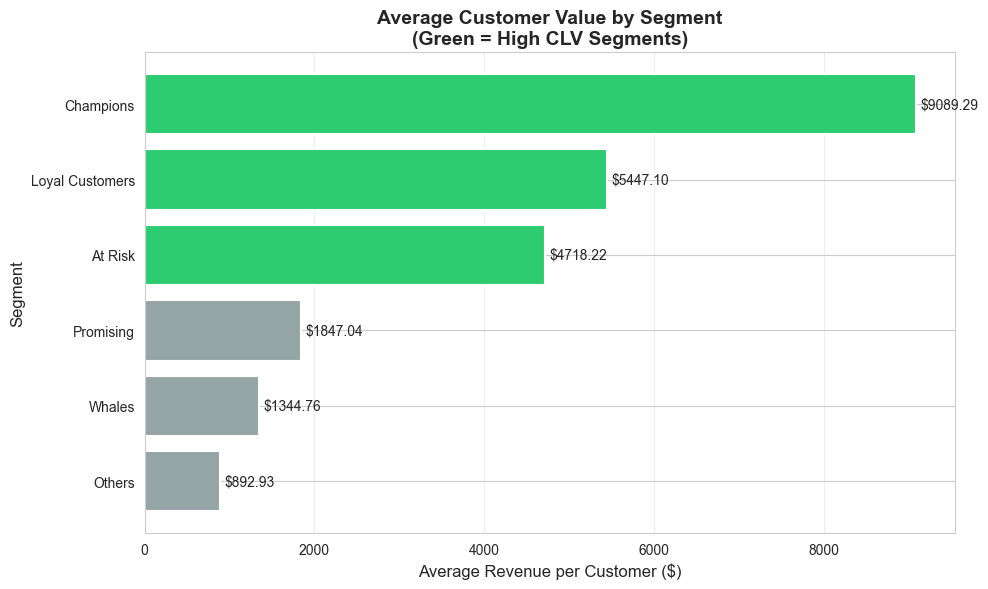

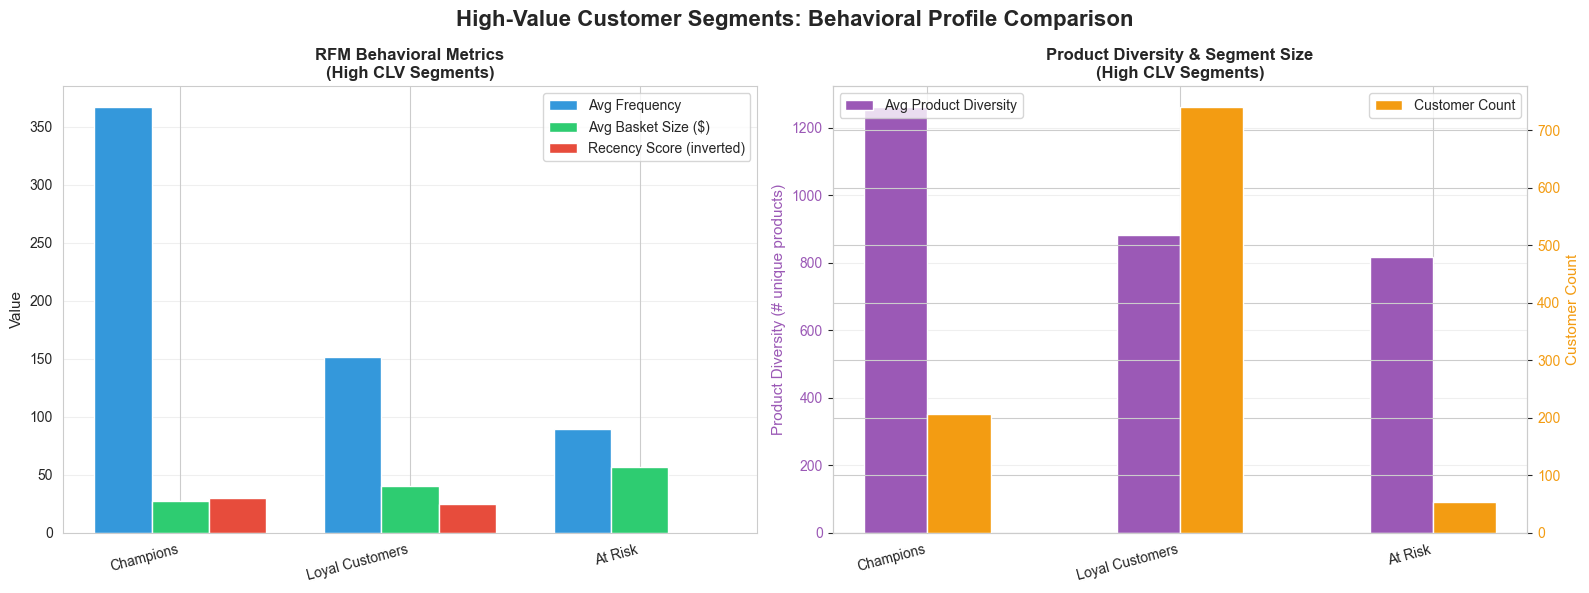

In [60]:
# 5.4 Visualization - Segment Value Analysis

# Calculate segment metrics
segment_metrics = customer_profile.groupby('segment').agg({
    'total_revenue': 'sum',
    'frequency': 'mean',
    'average_basket_size': 'mean',
    'recency': 'mean',
    'weighted_clv': 'mean'
})
segment_metrics['customer_count'] = customer_profile.groupby('segment').size()
segment_metrics['avg_revenue_per_customer'] = segment_metrics['total_revenue'] / segment_metrics['customer_count']

# ===== Figure 1: Average Customer Value by Segment =====
plt.figure(figsize=(10, 6))

# Sort by average revenue per customer
segment_metrics_sorted = segment_metrics.sort_values('avg_revenue_per_customer', ascending=True)

# Color-code by CLV tier
high_clv_segments = ['Champions', 'Loyal Customers', 'At Risk']
colors = ['#2ecc71' if seg in high_clv_segments else '#95a5a6' for seg in segment_metrics_sorted.index]

plt.barh(segment_metrics_sorted.index, segment_metrics_sorted['avg_revenue_per_customer'], 
         color=colors, edgecolor='white', linewidth=1.5)
plt.xlabel('Average Revenue per Customer ($)', fontsize=12)
plt.ylabel('Segment', fontsize=12)
plt.title('Average Customer Value by Segment\n(Green = High CLV Segments)', 
          fontsize=14, fontweight='bold')

# Add value labels
for i, v in enumerate(segment_metrics_sorted['avg_revenue_per_customer']):
    plt.text(v + 50, i, f'${v:.2f}', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# ===== Figure 2: High-Value Customer Profile Comparison =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('High-Value Customer Segments: Behavioral Profile Comparison', 
             fontsize=16, fontweight='bold')

# Focus on High CLV segments only
high_clv_data = customer_profile[customer_profile['segment'].isin(high_clv_segments)]
high_clv_metrics = high_clv_data.groupby('segment').agg({
    'frequency': 'mean',
    'average_basket_size': 'mean',
    'recency': 'mean',
    'product_diversity': 'mean'
})

# Left: RFM Comparison (Frequency, Basket Size, Recency)
x = range(len(high_clv_segments))
width = 0.25

# Normalize recency (inverse: lower is better)
max_recency = high_clv_metrics['recency'].max()
high_clv_metrics['recency_score'] = max_recency - high_clv_metrics['recency']

axes[0].bar([i - width for i in x], high_clv_metrics.loc[high_clv_segments, 'frequency'], 
            width, label='Avg Frequency', color='#3498db')
axes[0].bar([i for i in x], high_clv_metrics.loc[high_clv_segments, 'average_basket_size'], 
            width, label='Avg Basket Size ($)', color='#2ecc71')
axes[0].bar([i + width for i in x], high_clv_metrics.loc[high_clv_segments, 'recency_score'], 
            width, label='Recency Score (inverted)', color='#e74c3c')

axes[0].set_xticks(x)
axes[0].set_xticklabels(high_clv_segments, rotation=15, ha='right')
axes[0].set_ylabel('Value', fontsize=11)
axes[0].set_title('RFM Behavioral Metrics\n(High CLV Segments)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: Product Diversity & Customer Count
ax2_twin = axes[1].twinx()

bars1 = axes[1].bar([i - width/2 for i in x], 
                     high_clv_metrics.loc[high_clv_segments, 'product_diversity'], 
                     width, label='Avg Product Diversity', color='#9b59b6')
bars2 = ax2_twin.bar([i + width/2 for i in x], 
                      high_clv_data.groupby('segment').size().loc[high_clv_segments], 
                      width, label='Customer Count', color='#f39c12')

axes[1].set_xticks(x)
axes[1].set_xticklabels(high_clv_segments, rotation=15, ha='right')
axes[1].set_ylabel('Product Diversity (# unique products)', fontsize=11, color='#9b59b6')
ax2_twin.set_ylabel('Customer Count', fontsize=11, color='#f39c12')
axes[1].set_title('Product Diversity & Segment Size\n(High CLV Segments)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='y', labelcolor='#9b59b6')
ax2_twin.tick_params(axis='y', labelcolor='#f39c12')
axes[1].legend(loc='upper left')
ax2_twin.legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()